# CardioVision AI — Parte 2A: CNN Simples (do zero)

Classificação de imagens de ECG com uma **Convolutional Neural Network** construída do zero.

**Pré-requisito:** executar o notebook `01_preprocessing.ipynb` primeiro.

In [25]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPooling2D, Rescaling

## 1. Carregar conjuntos pré-processados

In [26]:

PROCESSED_PATH = Path("../data/processed")
METADATA_PATH = PROCESSED_PATH / "metadata.json"
MODELS_PATH = Path("../trained_models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

with open(METADATA_PATH, encoding="utf-8") as f:
    metadata = json.load(f)

class_names = metadata["class_names"]
num_classes = len(class_names)

print(f"Classes ({num_classes}): {class_names}")
print(f"Split — treino: {metadata['counts']['train']} | "
      f"validação: {metadata['counts']['validation']} | "
      f"teste: {metadata['counts']['test']}")

train_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_PATH / "train",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_PATH / "validation",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_PATH / "test",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Classes (4): ['batimento_cardiaco_anormal', 'historico_pos_infarto', 'infarto_do_miocardio', 'normal']
Split — treino: 649 | validação: 139 | teste: 140
Found 649 files belonging to 4 classes.
Found 139 files belonging to 4 classes.
Found 140 files belonging to 4 classes.


In [27]:

def collect_labels_and_predictions(dataset, model):
    y_true = np.concatenate([y.numpy() for _, y in dataset], axis=0)
    y_prob = model.predict(dataset, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    return y_true, y_pred, y_prob


def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="Treino")
    axes[0].plot(history.history["val_accuracy"], label="Validação")
    axes[0].set_title("Acurácia")
    axes[0].set_xlabel("Época")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history["loss"], label="Treino")
    axes[1].plot(history.history["val_loss"], label="Validação")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Época")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, dataset, split_name, model_title):
    loss, accuracy = model.evaluate(dataset, verbose=0)
    y_true, y_pred, _ = collect_labels_and_predictions(dataset, model)

    print(f"\n=== {model_title} — {split_name} ===")
    print(f"Acurácia: {accuracy:.4f} | Loss: {loss:.4f}")
    print("\nRelatório de classificação (precisão, recall, F1):")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
        ax=ax, xticks_rotation=45, cmap="Blues"
    )
    ax.set_title(f"Matriz de Confusão — {model_title} ({split_name})")
    plt.tight_layout()
    plt.show()

    return {"accuracy": accuracy, "loss": loss, "y_true": y_true, "y_pred": y_pred}


## 2. Arquitetura da CNN

Rede convolucional simples com 4 blocos Conv2D + MaxPooling, seguida de camadas densas.

In [28]:
MODEL_TITLE = "CNN do zero"

cnn_model = Sequential([
    Rescaling(1.0 / 255),
    Conv2D(32, 3, activation="relu", padding="same"),
    MaxPooling2D(),
    Conv2D(64, 3, activation="relu", padding="same"),
    MaxPooling2D(),
    Conv2D(128, 3, activation="relu", padding="same"),
    MaxPooling2D(),
    Conv2D(256, 3, activation="relu", padding="same"),
    MaxPooling2D(),
    Flatten(),
    Dense(512, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. Treinamento

In [29]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        str(MODELS_PATH / "cnn_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
)

cnn_model.save(MODELS_PATH / "cnn.keras")
print(f"Modelo salvo em {MODELS_PATH / 'cnn.keras'}")

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.2656 - loss: 2.6829
Epoch 1: val_accuracy improved from None to 0.30216, saving model to ..\trained_models\cnn_best.keras

Epoch 1: finished saving model to ..\trained_models\cnn_best.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 279ms/step - accuracy: 0.2820 - loss: 1.9285 - val_accuracy: 0.3022 - val_loss: 1.3749
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.2862 - loss: 1.3795
Epoch 2: val_accuracy did not improve from 0.30216
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.2974 - loss: 1.3789 - val_accuracy: 0.3022 - val_loss: 1.3736
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.2845 - loss: 1.3893
Epoch 3: val_accuracy did not improve from 0.30216
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step - accuracy: 0.3066 - loss: 1.3793 - val_accuracy: 0.3022 - val_loss: 1.3725
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.2906 - loss: 1.3736
Epoch 4: val_accuracy did not imp

## 4. Curvas de aprendizado

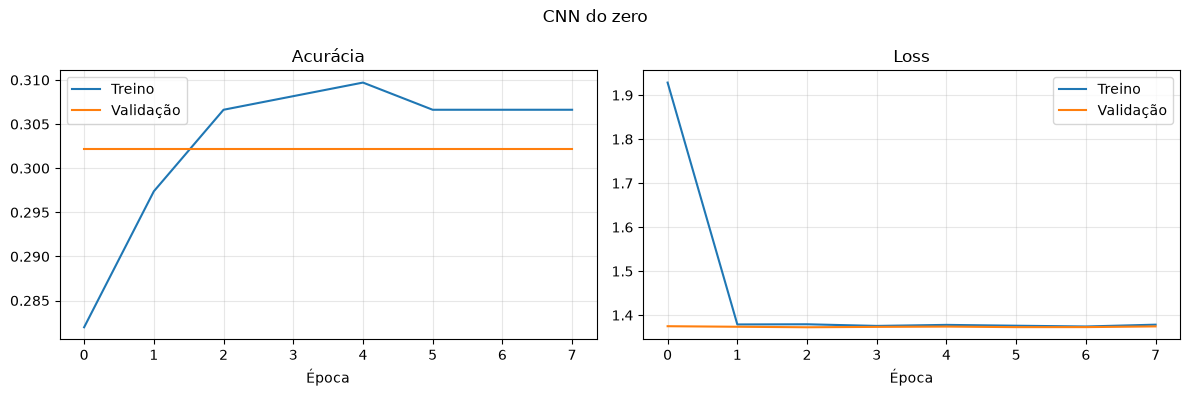

In [30]:
plot_training_history(history, MODEL_TITLE)

## 5. Métricas de avaliação (conjunto de teste)


=== CNN do zero — Teste ===
Acurácia: 0.3071 | Loss: 1.3713

Relatório de classificação (precisão, recall, F1):
                            precision    recall  f1-score   support

batimento_cardiaco_anormal       0.00      0.00      0.00        35
     historico_pos_infarto       0.00      0.00      0.00        26
      infarto_do_miocardio       0.00      0.00      0.00        36
                    normal       0.31      1.00      0.47        43

                  accuracy                           0.31       140
                 macro avg       0.08      0.25      0.12       140
              weighted avg       0.09      0.31      0.14       140



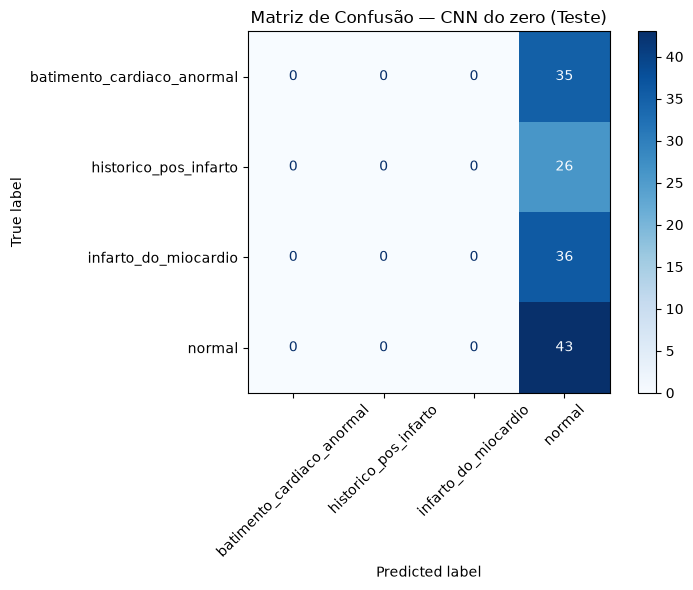

In [31]:
# Avaliação no conjunto de teste (métricas finais)
test_results = evaluate_model(cnn_model, test_ds, "Teste", MODEL_TITLE)

## 6. Protótipo interativo de classificação

In [32]:
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    print("Instale ipywidgets para o protótipo interativo: pip install ipywidgets")
else:
    sample_paths = sorted((PROCESSED_PATH / "test").rglob("*.jpg"))

    def predict_ecg(image_path: str):
        img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
        arr = tf.keras.utils.img_to_array(img)
        batch = tf.expand_dims(arr, axis=0)
        probs = cnn_model.predict(batch, verbose=0)[0]
        pred_idx = int(np.argmax(probs))

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(arr.astype("uint8"))
        axes[0].set_title(Path(image_path).name)
        axes[0].axis("off")

        axes[1].barh(class_names, probs, color="steelblue")
        axes[1].set_xlim(0, 1)
        axes[1].set_xlabel("Probabilidade")
        axes[1].set_title(f"Predição: {class_names[pred_idx]} ({probs[pred_idx]:.1%})")
        plt.tight_layout()
        plt.show()

    dropdown = widgets.Dropdown(
        options=[(p.name, str(p)) for p in sample_paths[:50]],
        description="Imagem:",
        layout=widgets.Layout(width="80%"),
    )
    button = widgets.Button(description="Classificar", button_style="primary")
    output = widgets.Output()

    def on_click(_):
        with output:
            output.clear_output(wait=True)
            predict_ecg(dropdown.value)

    button.on_click(on_click)
    display(widgets.VBox([widgets.HTML("<b>Simulador — CNN CardioVision</b>"), dropdown, button, output]))